In [1]:
from datetime import timedelta, datetime
import pprint

import ee
from IPython.display import Image, display
import ipyplot
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import openet.core

ee.Initialize()

In [2]:
monthly_coll = ee.ImageCollection('projects/openet/assets/ssebop/conus/gridmet/monthly/v2_1')
band_name = 'et'

years = list(range(2020, 2026))

region = ee.Geometry.BBox(-125.5, 25, -66, 50)
#region = ee.Geometry.BBox(-125.5, 25, -85.5, 50)
#region = ee.Geometry.BBox(-125.0, 25, -86.0, 50)

image_size = 512

et_palette = ['DEC29B', 'E6CDA1', 'EDD9A6', 'F5E4A9', 'FFF4AD', 'C3E683', '6BCC5C', '3BB369', '20998F', '1C8691', '16678A', '114982', '0B2C7A']
viridis = ['440154', '433982', '30678D', '218F8B', '36B677', '8ED542', 'FDE725']
# et_vis = {min: 0, max: 150, palette: et_palette}

land_mask = ee.Image('projects/openet/assets/features/water_mask').Not()
# Apply the NLCD/NALCMS water mask (anywhere it is water, set the ocean mask 
land_mask = land_mask.where(ee.Image("USGS/NLCD_RELEASES/2020_REL/NALCMS").unmask(18).eq(18), 0)
# land_mask = land_mask.And(ee.Image("USGS/NLCD_RELEASES/2020_REL/NALCMS").unmask(18).neq(18))
# # land_mask = ee.Image('projects/openet/assets/meteorology/conus404/ancillary/land_mask')


In [3]:
def mask_count_zero(img):
    mask_img = img.select(['count']).gt(0)
    return img.updateMask(mask_img)
    

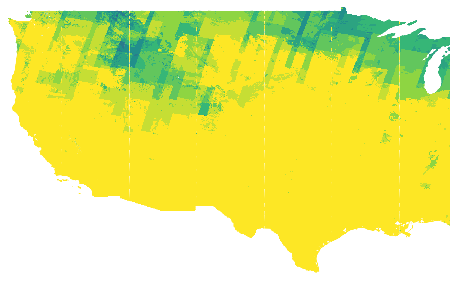

In [4]:
year = 2022
image_url = (
    monthly_coll.filterDate(f'{year}-01-01', f'{year+1}-01-01').select([band_name]).count()
    .visualize(min=0, max=12, palette=viridis)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -85.5, 50), 'dimensions': 450})
)
Image(image_url, embed=True, format='png')  

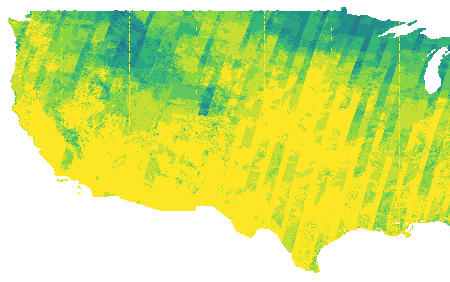

In [5]:
year = 2022
image_url = (
    monthly_coll.filterDate(f'{year}-01-01', f'{year+1}-01-01').map(mask_count_zero).select([band_name]).count()
    .visualize(min=0, max=12, palette=viridis)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -85.5, 50), 'dimensions': 450})
)
Image(image_url, embed=True, format='png')  

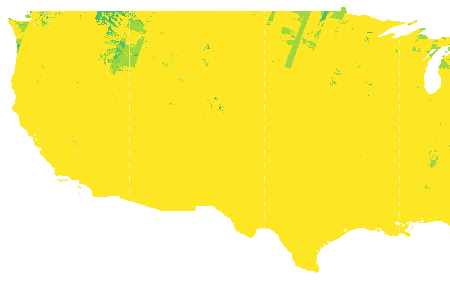

In [6]:
year = 2022
image_url = (
    monthly_coll.filterDate(f'{year}-04-01', f'{year}-11-01').select([band_name]).count()
    .visualize(min=0, max=7, palette=viridis)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -85.5, 50), 'dimensions': 450})
)
Image(image_url, embed=True, format='png') 

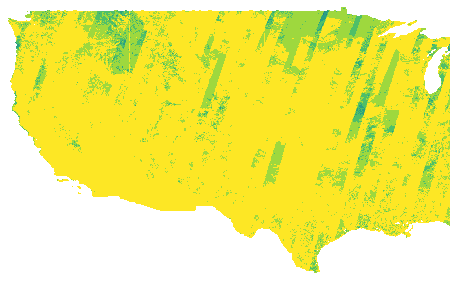

In [7]:
year = 2022
image_url = (
    monthly_coll.filterDate(f'{year}-04-01', f'{year}-11-01').map(mask_count_zero).select([band_name]).count()
    .visualize(min=0, max=7, palette=viridis)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -85.5, 50), 'dimensions': 450})
)
Image(image_url, embed=True, format='png')  

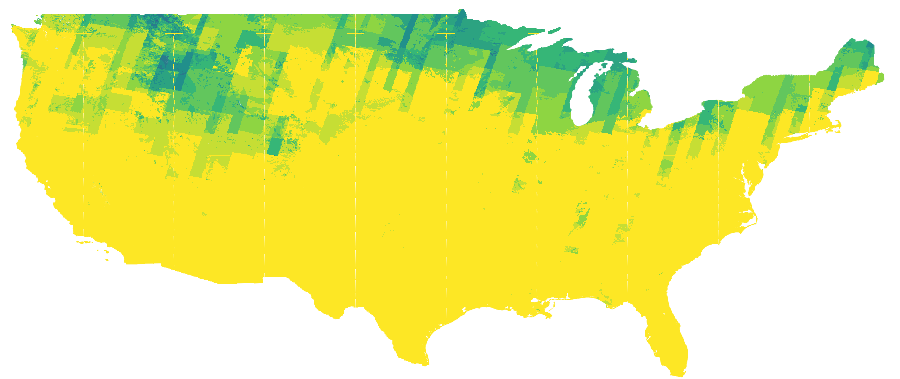

In [8]:
year = 2022
image_url = (
    monthly_coll.filterDate(f'{year}-01-01', f'{year+1}-01-01').select([band_name]).count()
    .visualize(min=0, max=12, palette=viridis)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -66, 50), 'dimensions': 900})
)
Image(image_url, embed=True, format='png')  

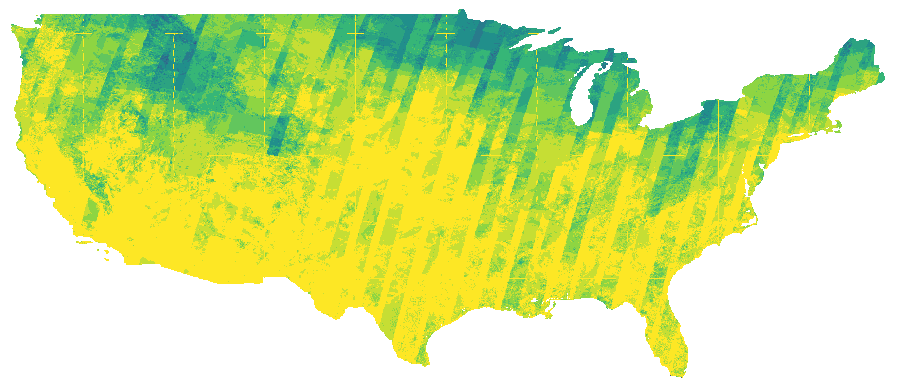

In [9]:
year = 2022
image_url = (
    monthly_coll.filterDate(f'{year}-01-01', f'{year+1}-01-01').map(mask_count_zero).select([band_name]).count()
    .visualize(min=0, max=12, palette=viridis)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -66, 50), 'dimensions': 900})
)
Image(image_url, embed=True, format='png')  

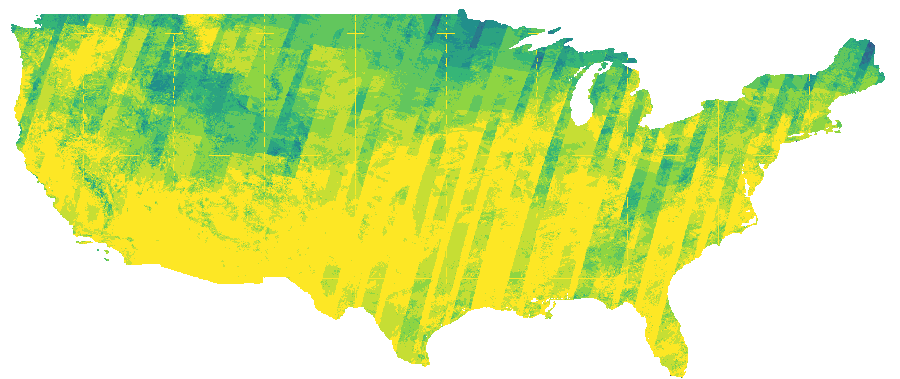

In [10]:
year = 2023
image_url = (
    monthly_coll.filterDate(f'{year}-01-01', f'{year+1}-01-01').map(mask_count_zero).select([band_name]).count()
    .visualize(min=0, max=12, palette=viridis)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -66, 50), 'dimensions': 900})
)
Image(image_url, embed=True, format='png')  

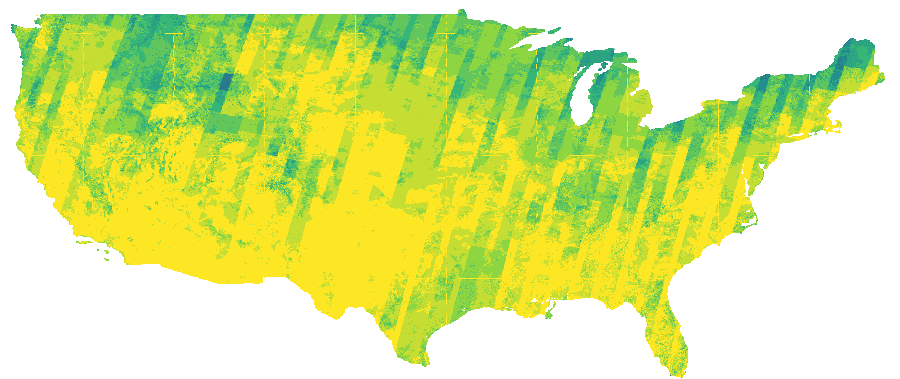

In [11]:
year = 2024
image_url = (
    monthly_coll.filterDate(f'{year}-01-01', f'{year+1}-01-01').map(mask_count_zero).select([band_name]).count()
    .visualize(min=0, max=12, palette=viridis)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -66, 50), 'dimensions': 900})
)
Image(image_url, embed=True, format='png')  

In [12]:
for year in years:
    print(year)
    with_count_zero_url = (
        monthly_coll.filterDate(f'{year}-01-01', f'{year+1}-01-01').select([band_name]).count()
        .visualize(min=0, max=12, palette=viridis)
        .getThumbURL({'region': region, 'dimensions': image_size})
    )
    no_count_zero_url = (
        monthly_coll.filterDate(f'{year}-01-01', f'{year+1}-01-01').map(mask_count_zero).select([band_name]).count()
        .visualize(min=0, max=12, palette=viridis)
        .getThumbURL({'region': region, 'dimensions': image_size})
    )
    ipyplot.plot_images([with_count_zero_url, no_count_zero_url], labels=['With Count Zero Months', 'Without Count Zero Months'], show_url=False, img_width=image_size)
    #break

2020


2021


2022


2023


2024


2025
